In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [80]:
faostat = pd.read_csv("FAOSTAT.csv")

In [81]:
faostat.head()

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,QCL,Crops and livestock products,204,Benin,5412,Yield,1520.01,"Cassava, fresh",1961,1961,kg/ha,3783.8,E,Estimated value,NaN
1,QCL,Crops and livestock products,204,Benin,5412,Yield,1520.01,"Cassava, fresh",1962,1962,kg/ha,3902.4,E,Estimated value,NaN
2,QCL,Crops and livestock products,204,Benin,5412,Yield,1520.01,"Cassava, fresh",1963,1963,kg/ha,3928.6,E,Estimated value,NaN
3,QCL,Crops and livestock products,204,Benin,5412,Yield,1520.01,"Cassava, fresh",1964,1964,kg/ha,3888.9,E,Estimated value,NaN
4,QCL,Crops and livestock products,204,Benin,5412,Yield,1520.01,"Cassava, fresh",1965,1965,kg/ha,4081.6,E,Estimated value,NaN


In [82]:
import os

os.getcwd()

'C:\\Users\\USER\\Agricultural'

In [14]:
os.listdir()


['.ipynb_checkpoints',
 'Agricultural Yield Predictor.ipynb',
 'FAOSTAT.csv',
 'NASA POWER.csv']

In [83]:
faostat.shape

(11616, 15)

In [23]:
faostat.columns

Index(['Domain Code', 'Domain', 'Area Code (M49)', 'Area', 'Element Code',
       'Element', 'Item Code (CPC)', 'Item', 'Year Code', 'Year', 'Unit',
       'Value', 'Flag', 'Flag Description', 'Note'],
      dtype='object')

In [25]:
faostat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11616 entries, 0 to 11615
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Domain Code       11616 non-null  object 
 1   Domain            11616 non-null  object 
 2   Area Code (M49)   11616 non-null  int64  
 3   Area              11616 non-null  object 
 4   Element Code      11616 non-null  int64  
 5   Element           11616 non-null  object 
 6   Item Code (CPC)   11616 non-null  float64
 7   Item              11616 non-null  object 
 8   Year Code         11616 non-null  int64  
 9   Year              11616 non-null  int64  
 10  Unit              11616 non-null  object 
 11  Value             11616 non-null  float64
 12  Flag              11616 non-null  object 
 13  Flag Description  11616 non-null  object 
 14  Note              0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [26]:
faostat_clean = faostat.copy()

In [84]:
faostat_data = faostat.copy()

In [85]:
columns_to_drop = [
    "Domain Code",
    "Domain",
    "Area Code (M49)",
    "Element Code",
    "Item Code (CPC)",
    "Year Code",
    "Flag Description",
    "Note"
]

faostat_data.drop(
    columns=columns_to_drop,
    inplace=True,
    errors="ignore"
)

In [86]:
faostat_data.head()

,Area,Element,Item,Year,Unit,Value,Flag
0,Benin,Yield,"Cassava, fresh",1961,kg/ha,3783.8,E
1,Benin,Yield,"Cassava, fresh",1962,kg/ha,3902.4,E
2,Benin,Yield,"Cassava, fresh",1963,kg/ha,3928.6,E
3,Benin,Yield,"Cassava, fresh",1964,kg/ha,3888.9,E
4,Benin,Yield,"Cassava, fresh",1965,kg/ha,4081.6,E


In [35]:
faostat_data.columns

Index(['Area', 'Element', 'Item', 'Year', 'Unit', 'Value', 'Flag'], dtype='object')

In [37]:
faostat_data.describe()

,Year,Value
count,11616.000000,11616.000000
mean,1993.383178,6286.231207
std,18.439457,13653.777239
min,1961.000000,0.100000
25%,1978.000000,721.275000
50%,1994.000000,1315.100000
75%,2009.000000,6391.425000
max,2024.000000,120096.200000


In [36]:
faostat_data.sample

<bound method NDFrame.sample of         Area Element            Item  Year   Unit   Value Flag
0      Benin   Yield  Cassava, fresh  1961  kg/ha  3783.8    E
1      Benin   Yield  Cassava, fresh  1962  kg/ha  3902.4    E
2      Benin   Yield  Cassava, fresh  1963  kg/ha  3928.6    E
3      Benin   Yield  Cassava, fresh  1964  kg/ha  3888.9    E
4      Benin   Yield  Cassava, fresh  1965  kg/ha  4081.6    E
...      ...     ...             ...   ...    ...     ...  ...
11611   Togo   Yield            Yams  2020  kg/ha  9034.6    A
11612   Togo   Yield            Yams  2021  kg/ha  9037.1    A
11613   Togo   Yield            Yams  2022  kg/ha  9043.9    A
11614   Togo   Yield            Yams  2023  kg/ha  8965.5    E
11615   Togo   Yield            Yams  2024  kg/ha  8976.1    E

[11616 rows x 7 columns]>

In [38]:
import pandas as pd

descriptions = {
    "Area": 
        "Country where the agricultural observation was recorded",

    "Item": 
        "Name of the crop",

    "Element": 
        "Agricultural measurement type (Yield, Production, Area harvested)",

    "Year": 
        "Calendar year of the observation",

    "Unit": 
        "Measurement unit of the recorded value (kg/ha for yield)",

    "Value": 
        "Observed agricultural value. Yield (kg/ha) is the prediction target",

    "Flag": 
        "Data quality indicator describing the reliability of the observation"
}


data_dict = pd.DataFrame({
    "Column": faostat_clean.columns,
    "Dtype": [
        str(faostat_clean[c].dtype) 
        for c in faostat_clean.columns
    ],
    "Non-Null": [
        faostat_clean[c].notna().sum()
        for c in faostat_clean.columns
    ],
    "Null": [
        faostat_clean[c].isna().sum()
        for c in faostat_clean.columns
    ],
    "Unique": [
        faostat_clean[c].nunique()
        for c in faostat_clean.columns
    ],
    "Sample": [
        faostat_clean[c].dropna().iloc[0]
        if faostat_clean[c].notna().any()
        else None
        for c in faostat_clean.columns
    ],
    "Description": [
        descriptions.get(c, "")
        for c in faostat_clean.columns
    ]
})


data_dict

,Column,Dtype,Non-Null,Null,Unique,Sample,Description
0,Domain Code,object,11616,0,1,QCL,
1,Domain,object,11616,0,1,Crops and livestock products,
2,Area Code (M49),int64,11616,0,16,204,
3,Area,object,11616,0,16,Benin,Country where the agricultural observation was...
4,Element Code,int64,11616,0,1,5412,
5,Element,object,11616,0,1,Yield,"Agricultural measurement type (Yield, Producti..."
6,Item Code (CPC),float64,11616,0,16,1520.01,
7,Item,object,11616,0,16,"Cassava, fresh",Name of the crop
8,Year Code,int64,11616,0,64,1961,
9,Year,int64,11616,0,64,1961,Calendar year of the observation


In [87]:
import pandas as pd

descriptions = {
    "Area": 
        "Country where the agricultural observation was recorded",
    "Item": 
        "Name of the crop",
    "Element": 
        "Agricultural measurement type (Yield, Production, Area harvested)",
    "Year": 
        "Calendar year of the observation",
    "Unit": 
        "Measurement unit of the recorded value (kg/ha for yield)",
    "Value": 
        "Observed agricultural value. Yield (kg/ha) is the prediction target",
    "Flag": 
        "Data quality indicator describing the reliability of the observation"
}
data_dict = pd.DataFrame({
    "Column": faostat_data.columns,
    "Dtype": [
        str(faostat_data[c].dtype) 
        for c in faostat_data.columns
    ],
    "Non-Null": [
        faostat_data[c].notna().sum()
        for c in faostat_data.columns
    ],
    "Null": [
       faostat_data[c].isna().sum()
        for c in faostat_data.columns
    ],
    "Unique": [
        faostat_data[c].nunique()
        for c in faostat_data.columns
    ],
    "Sample": [
        faostat_data[c].dropna().iloc[0]
        if faostat_data[c].notna().any()
        else None
        for c in faostat_data.columns
    ],
    "Description": [
        descriptions.get(c, "")
        for c in faostat_data.columns
    ]
})


data_dict

,Column,Dtype,Non-Null,Null,Unique,Sample,Description
0,Area,object,11616,0,16,Benin,Country where the agricultural observation was...
1,Element,object,11616,0,1,Yield,"Agricultural measurement type (Yield, Producti..."
2,Item,object,11616,0,16,"Cassava, fresh",Name of the crop
3,Year,int64,11616,0,64,1961,Calendar year of the observation
4,Unit,object,11616,0,1,kg/ha,Measurement unit of the recorded value (kg/ha ...
5,Value,float64,11616,0,8547,3783.8,Observed agricultural value. Yield (kg/ha) is ...
6,Flag,object,11616,0,3,E,Data quality indicator describing the reliabil...


In [40]:
faostat_data.shape

(11616, 7)

In [43]:


crop_summary = (
    faostat_data.groupby("Item")["Value"]
    .agg(
        Records="count",
        Mean_Yield="mean",
        Min_Yield="min",
        Max_Yield="max"
    )
    .round(2)
    .sort_values("Records", ascending=False)
    .reset_index()
)

print(f"Unique crops: {len(crop_summary)}")

crop_summary.to_csv(
    os.path.join(OUTPUT_DIR, "crop_summary.csv"),
    index=False
)

crop_summary

Unique crops: 16


,Item,Records,Mean_Yield,Min_Yield,Max_Yield
0,"Groundnuts, excluding shelled",985,850.20,66.4,2436.9
1,Maize (corn),960,1092.25,0.1,3334.9
2,Rice,960,1856.10,355.8,5663.9
3,"Cassava, fresh",937,8760.95,1835.2,32591.3
4,Millet,896,769.59,65.5,1906.5
5,Sorghum,879,837.81,125.7,1794.1
6,Sweet potatoes,867,6968.77,350.0,46084.1
7,Tomatoes,760,10279.12,1777.8,33218.2
8,Sugar cane,735,46014.14,1000.0,120096.2
9,"Seed cotton, unginned",711,907.54,94.1,3066.7


In [42]:
import os

OUTPUT_DIR = "outputs"

os.makedirs(OUTPUT_DIR, exist_ok=True)

Unique countries: 16


,Area,Records,Mean_Yield,Min_Yield,Max_Yield
0,Nigeria,990,4881.21,94.1,41071.4
1,Côte d'Ivoire,917,6283.05,250.0,81007.0
2,Burkina Faso,883,9487.59,102.6,108152.2
3,Ghana,868,5990.63,205.4,53191.5
4,Mali,866,8901.75,62.1,79818.6
5,Benin,820,4845.13,120.4,42967.8
6,Guinea,815,6333.70,100.0,53923.2
7,Niger,785,7009.61,48.7,60200.7
8,Senegal,762,12182.86,63.7,120096.2
9,Togo,695,2928.05,110.5,20350.0


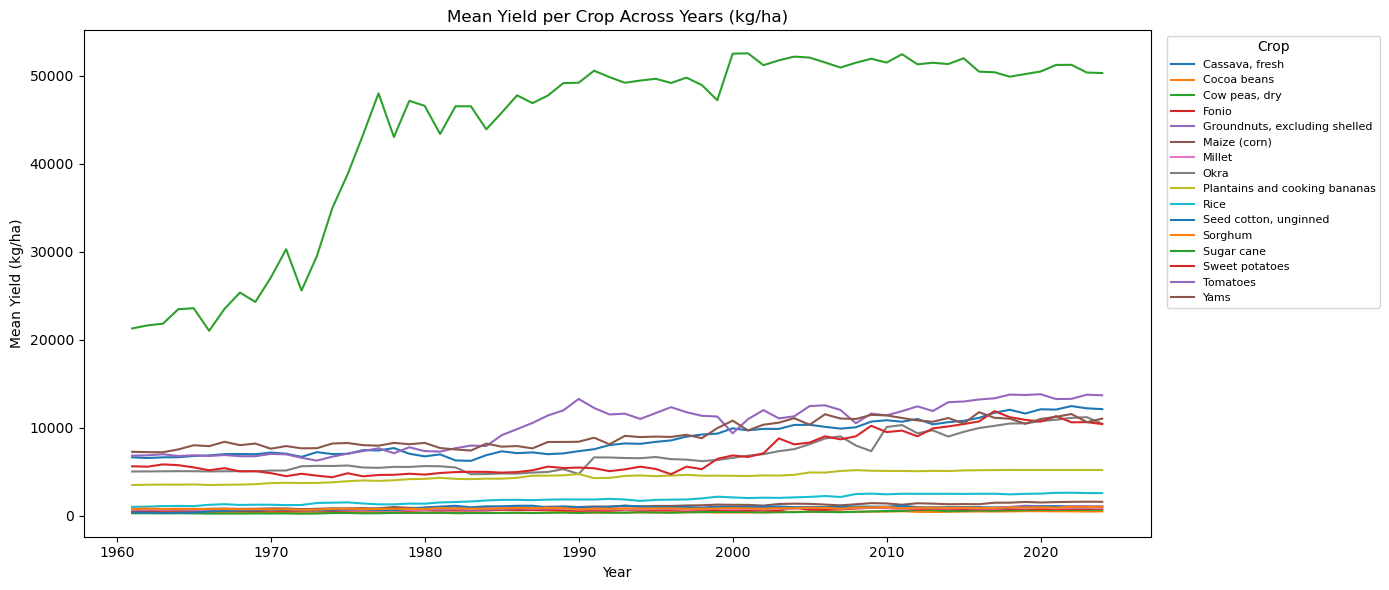

In [46]:
pivot_crop = faostat_data.groupby(["Year", "Item"])["Value"].mean().unstack("Item")

fig, ax = plt.subplots(figsize=(14, 6))
pivot_crop.plot(ax=ax)
ax.set_title("Mean Yield per Crop Across Years (kg/ha)")
ax.set_xlabel("Year")
ax.set_ylabel("Mean Yield (kg/ha)")
ax.legend(title="Crop", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "yield_per_crop_over_years.png"), dpi=150, bbox_inches="tight")
plt.show()

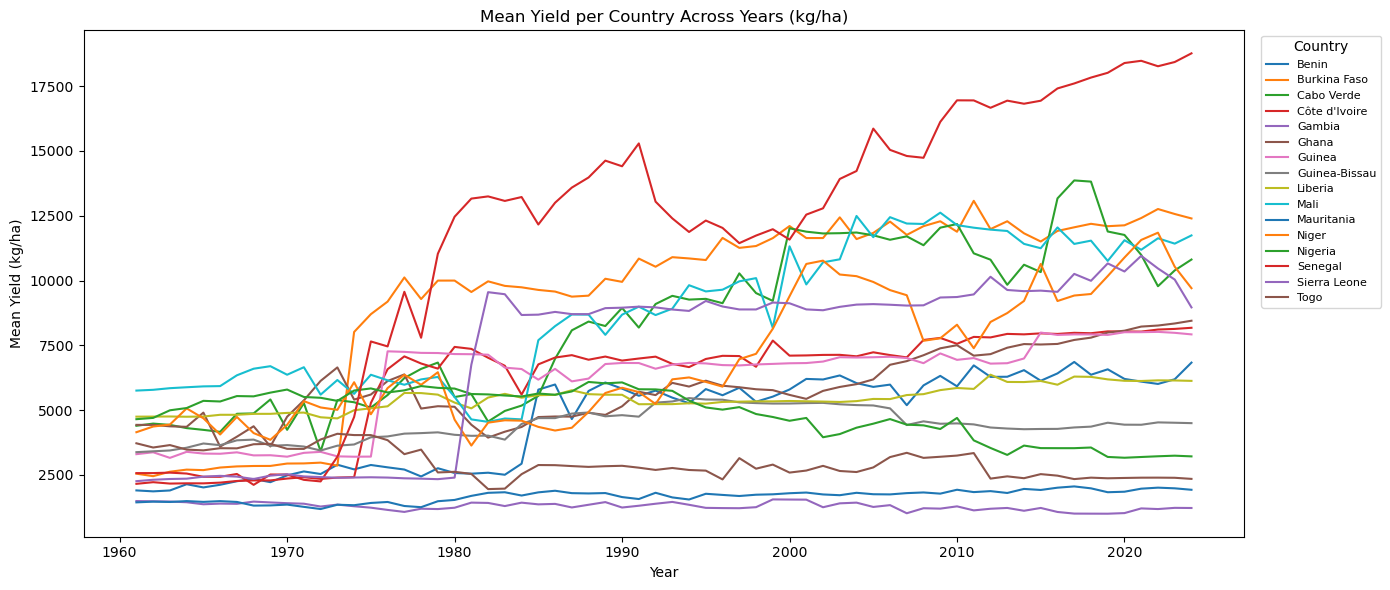

In [47]:
# Mean yield per country across years
pivot_country = faostat_data.groupby(["Year", "Area"])["Value"].mean().unstack("Area")

fig, ax = plt.subplots(figsize=(14, 6))
pivot_country.plot(ax=ax)
ax.set_title("Mean Yield per Country Across Years (kg/ha)")
ax.set_xlabel("Year")
ax.set_ylabel("Mean Yield (kg/ha)")
ax.legend(title="Country", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "yield_per_country_over_years.png"), dpi=150, bbox_inches="tight")
plt.show()

In [48]:
import pandas as pd

In [7]:


import pandas as pd


centroid_df = pd.DataFrame({
    "Country": [
        "Benin",
        "Burkina Faso",
        "Cape Verde",
        "Cote d'Ivoire",
        "Gambia",
        "Ghana",
        "Guinea",
        "Guinea-Bissau",
        "Liberia",
        "Mali",
        "Mauritania",
        "Niger",
        "Nigeria",
        "Senegal",
        "Sierra Leone",
        "Togo"
    ],
    
    "Latitude": [
        9.3077,
        12.2383,
        16.5388,
        7.5400,
        13.4432,
        7.9465,
        9.9456,
        11.8037,
        6.4281,
        17.5707,
        21.0079,
        17.6078,
        9.0820,
        14.4974,
        8.4606,
        8.6195
    ],
    
    "Longitude": [
        2.3158,
        -1.5616,
        -23.0418,
        -5.5471,
        -15.3101,
        -1.0232,
        -9.6966,
        -15.1804,
        -9.4295,
        -3.9962,
        -10.9408,
        8.0817,
        8.6753,
        -14.4524,
        -11.7799,
        0.8248
    ]
})

print(f"Number of countries: {len(centroid_df)}")

centroid_df

Number of countries: 16


,Country,Latitude,Longitude
0,Benin,9.3077,2.3158
1,Burkina Faso,12.2383,-1.5616
2,Cape Verde,16.5388,-23.0418
3,Cote d'Ivoire,7.5400,-5.5471
4,Gambia,13.4432,-15.3101
5,Ghana,7.9465,-1.0232
6,Guinea,9.9456,-9.6966
7,Guinea-Bissau,11.8037,-15.1804
8,Liberia,6.4281,-9.4295
9,Mali,17.5707,-3.9962


In [9]:
centroid_df.columns

Index(['Country', 'Latitude', 'Longitude'], dtype='object')

In [10]:
import requests
import pandas as pd
import time

In [11]:
BASE_URL = "https://power.larc.nasa.gov/api/temporal/monthly/point"

COMMUNITY = "AG"

FORMAT = "JSON"

START_YEAR = 1963
END_YEAR = 2023

In [35]:
PARAMETERS = ",".join([

    # Solar radiation
    "ALLSKY_SFC_SW_DWN",   # All Sky Surface Shortwave Downward Irradiance
    "ALLSKY_SFC_PAR_TOT",  # Photosynthetically Active Radiation (PAR)

    # Temperature
    "T2M",                 # Temperature at 2 Meters
    "T2M_MAX",             # Maximum Temperature at 2 Meters
    "T2M_MIN",             # Minimum Temperature at 2 Meters
    "TS",                  # Earth Skin Temperature

    # Humidity / Precipitation
    "RH2M",                # Relative Humidity at 2 Meters
    "PRECTOTCORR",         # Corrected Precipitation

    # Wind / Pressure
    "PS",                  # Surface Pressure
    "WS2M"                 # Wind Speed at 2 Meters
])


In [36]:
import requests 
import pandas as pd

def fetch_weather_data(country, lat, lon):

    api_request_url = (
        f"{BASE_URL}"
        f"?parameters={PARAMETERS}"
        f"&community={COMMUNITY}"
        f"&longitude={lon}"
        f"&latitude={lat}"
        f"&start={START_YEAR}"
        f"&end={END_YEAR}"
        f"&format={FORMAT}"
    )

    print(api_request_url)

    response = requests.get(api_request_url, timeout=30)

    print(response.status_code)

    response.raise_for_status()

    data = response.json()

    print(data.keys())

    parameter_data = data["properties"]["parameter"]

    df_country = pd.DataFrame(parameter_data)

    print(df_country.head())

    return df_country

In [37]:
fetch_weather_data

<function __main__.fetch_weather_data(country, lat, lon)>

In [38]:
weather = fetch_weather_data(
    "Benin",
    9.3077,
    2.3158
)

https://power.larc.nasa.gov/api/temporal/monthly/point?parameters=ALLSKY_SFC_SW_DWN,ALLSKY_SFC_PAR_TOT,T2M,T2M_MAX,T2M_MIN,TS,RH2M,PRECTOTCORR,PS,WS2M&community=AG&longitude=2.3158&latitude=9.3077&start=1963&end=2023&format=JSON
422


HTTPError: 422 Client Error:  for url: https://power.larc.nasa.gov/api/temporal/monthly/point?parameters=ALLSKY_SFC_SW_DWN,ALLSKY_SFC_PAR_TOT,T2M,T2M_MAX,T2M_MIN,TS,RH2M,PRECTOTCORR,PS,WS2M&community=AG&longitude=2.3158&latitude=9.3077&start=1963&end=2023&format=JSON

In [33]:
print(weather)

None


In [39]:
import requests
import pandas as pd
import time
import os

In [50]:
BASE_URL   = "https://power.larc.nasa.gov/api/temporal/monthly/point"

COMMUNITY  = "AG"

FORMAT     = "JSON"

START_YEAR = 1981
END_YEAR   = 2023


PARAMETERS = ",".join([

    # Solar Fluxes
    "ALLSKY_SFC_SW_DWN",   # All Sky Surface Shortwave Downward Irradiance
    "ALLSKY_SFC_PAR_TOT",  # All Sky Surface PAR Total

    # Temperature
    "T2M",                 # Temperature at 2 Meters
    "T2M_MAX",             # Temperature at 2 Meters Maximum
    "T2M_MIN",             # Temperature at 2 Meters Minimum
    "TS",                  # Earth Skin Temperature

    # Humidity / Precipitation
    "RH2M",                # Relative Humidity at 2 Meters
    "PRECTOTCORR",         # Precipitation Average

    # Wind / Pressure
    "PS",                  # Surface Pressure
    "WS2M"                 # Wind Speed at 2 Meters

])

In [51]:
def fetch_weather_data(country, lat, lon):

    api_request_url = (
        f"{BASE_URL}"
        f"?parameters={PARAMETERS}"
        f"&community={COMMUNITY}"
        f"&longitude={lon}"
        f"&latitude={lat}"
        f"&start={START_YEAR}"
        f"&end={END_YEAR}"
        f"&format={FORMAT}"
    )


    try:
        response = requests.get(
            url=api_request_url,
            verify=True,
            timeout=30
        )
        response.raise_for_status()
        data = response.json()
        parameter_data = data["properties"]["parameter"]
        df_country = pd.DataFrame(parameter_data)
        # Convert index into column
        df_country.index.name = "YearMonth"

        df_country = df_country.reset_index()
        # NASA POWER annual value ends with 13
        df_country = df_country[
            df_country["YearMonth"].str.endswith("13")
        ].copy()
        # Extract year
        df_country["Year"] = (
            df_country["YearMonth"]
            .str[:4]
            .astype(int)
        )
        # Remove unnecessary column
        df_country.drop(
            columns=["YearMonth"],
            inplace=True
        )
        # Add country
        df_country["Area"] = country
        # Put columns in desired order
        df_country = df_country[
            [
                "ALLSKY_SFC_PAR_TOT",
                "ALLSKY_SFC_SW_DWN",
                "PRECTOTCORR",
                "PS",
                "RH2M",
                "T2M",
                "T2M_MAX",
                "T2M_MIN",
                "TS",
                "WS2M",
                "Year",
                "Area"
            ]
        ]
        print(
            f"✓ {country} - {len(df_country)} years retrieved"
        )
        return df_country
    except Exception as e:
        print(
            f"✗ {country} - Error: {e}"
        )
        return None

In [52]:
all_weather_data = []


for idx, row in centroid_df.iterrows():

    country = row["Country"]

    lat = row["Latitude"]

    lon = row["Longitude"]
    df_weather = fetch_weather_data(
        country,
        lat,
        lon
    )
    if df_weather is not None:

        all_weather_data.append(df_weather)
    # Pause pour éviter de surcharger NASA API
    time.sleep(2)

✓ Benin - 43 years retrieved
✓ Burkina Faso - 43 years retrieved
✓ Cape Verde - 43 years retrieved
✓ Cote d'Ivoire - 43 years retrieved
✓ Gambia - 43 years retrieved
✓ Ghana - 43 years retrieved
✓ Guinea - 43 years retrieved
✓ Guinea-Bissau - 43 years retrieved
✓ Liberia - 43 years retrieved
✓ Mali - 43 years retrieved
✓ Mauritania - 43 years retrieved
✓ Niger - 43 years retrieved
✓ Nigeria - 43 years retrieved
✓ Senegal - 43 years retrieved
✓ Sierra Leone - 43 years retrieved
✓ Togo - 43 years retrieved


In [60]:
weather_df = pd.concat(
    all_weather_data,
    ignore_index=True
)

In [61]:
weather_df.head()

,ALLSKY_SFC_PAR_TOT,ALLSKY_SFC_SW_DWN,PRECTOTCORR,PS,RH2M,T2M,T2M_MAX,T2M_MIN,TS,WS2M,Year,Area
0,-999.00,-999.00,3.76,97.28,74.53,24.76,37.44,12.21,24.86,1.80,1981,Benin
1,-999.00,-999.00,3.33,97.27,72.14,25.02,36.93,12.56,25.40,1.85,1982,Benin
2,-999.00,-999.00,2.30,97.28,59.62,26.85,41.36,13.34,27.90,2.13,1983,Benin
3,9.96,19.59,3.05,97.19,66.79,25.88,39.42,14.83,26.61,1.93,1984,Benin
4,9.75,19.68,3.37,97.22,67.67,25.65,40.02,13.78,26.30,1.94,1985,Benin


In [55]:
cols = weather_df.columns.tolist()
cols.remove("Area")
cols.remove("Year")
cols = ["Area", "Year"] + cols
weather_df = weather_df[cols]

In [59]:
weather_df.head()

,Area,Year,ALLSKY_SFC_PAR_TOT,ALLSKY_SFC_SW_DWN,PRECTOTCORR,PS,RH2M,T2M,T2M_MAX,T2M_MIN,TS,WS2M
0,Benin,1981,-999.00,-999.00,3.76,97.28,74.53,24.76,37.44,12.21,24.86,1.80
1,Benin,1982,-999.00,-999.00,3.33,97.27,72.14,25.02,36.93,12.56,25.40,1.85
2,Benin,1983,-999.00,-999.00,2.30,97.28,59.62,26.85,41.36,13.34,27.90,2.13
3,Benin,1984,9.96,19.59,3.05,97.19,66.79,25.88,39.42,14.83,26.61,1.93
4,Benin,1985,9.75,19.68,3.37,97.22,67.67,25.65,40.02,13.78,26.30,1.94


In [58]:
weather_df

,Area,Year,ALLSKY_SFC_PAR_TOT,ALLSKY_SFC_SW_DWN,PRECTOTCORR,PS,RH2M,T2M,T2M_MAX,T2M_MIN,TS,WS2M
0,Benin,1981,-999.00,-999.00,3.76,97.28,74.53,24.76,37.44,12.21,24.86,1.80
1,Benin,1982,-999.00,-999.00,3.33,97.27,72.14,25.02,36.93,12.56,25.40,1.85
2,Benin,1983,-999.00,-999.00,2.30,97.28,59.62,26.85,41.36,13.34,27.90,2.13
3,Benin,1984,9.96,19.59,3.05,97.19,66.79,25.88,39.42,14.83,26.61,1.93
4,Benin,1985,9.75,19.68,3.37,97.22,67.67,25.65,40.02,13.78,26.30,1.94
...,...,...,...,...,...,...,...,...,...,...,...,...
683,Togo,2019,8.35,18.23,4.20,97.12,77.77,25.48,36.24,13.64,25.48,1.59
684,Togo,2020,8.39,18.45,4.43,97.13,77.28,25.21,36.26,11.81,25.21,1.73
685,Togo,2021,8.43,18.48,4.00,97.10,77.34,25.58,36.12,15.19,25.67,1.60
686,Togo,2022,8.25,18.00,5.06,97.09,77.44,25.01,36.73,13.20,25.04,1.66


In [62]:
print(f"Columns in weather_df: {weather_df.columns.tolist()}")

Columns in weather_df: ['ALLSKY_SFC_PAR_TOT', 'ALLSKY_SFC_SW_DWN', 'PRECTOTCORR', 'PS', 'RH2M', 'T2M', 'T2M_MAX', 'T2M_MIN', 'TS', 'WS2M', 'Year', 'Area']


In [63]:
print(f"Shape of weather_df: {weather_df.shape}")

Shape of weather_df: (688, 12)


In [64]:
print("Weather DataFrame info:")
weather_df.info(verbose=True, show_counts=True)

Weather DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 688 entries, 0 to 687
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ALLSKY_SFC_PAR_TOT  688 non-null    float64
 1   ALLSKY_SFC_SW_DWN   688 non-null    float64
 2   PRECTOTCORR         688 non-null    float64
 3   PS                  688 non-null    float64
 4   RH2M                688 non-null    float64
 5   T2M                 688 non-null    float64
 6   T2M_MAX             688 non-null    float64
 7   T2M_MIN             688 non-null    float64
 8   TS                  688 non-null    float64
 9   WS2M                688 non-null    float64
 10  Year                688 non-null    int64  
 11  Area                688 non-null    object 
dtypes: float64(10), int64(1), object(1)
memory usage: 64.6+ KB


In [65]:
print("Summary statistics for numeric columns in weather_df:")
weather_df.describe()

Summary statistics for numeric columns in weather_df:


,ALLSKY_SFC_PAR_TOT,ALLSKY_SFC_SW_DWN,PRECTOTCORR,PS,RH2M,T2M,T2M_MAX,T2M_MIN,TS,WS2M,Year
count,688.000000,688.000000,688.000000,688.00000,688.000000,688.000000,688.000000,688.000000,688.000000,688.000000,688.000000
mean,-61.054288,-51.175945,2.892020,98.08234,59.164273,26.372442,40.282645,12.606003,27.072703,2.459884,2002.000000
std,257.054862,259.768522,2.115906,2.20629,20.653864,1.535665,4.415141,3.577491,1.811149,1.012641,12.418702
min,-999.000000,-999.000000,0.040000,93.57000,16.710000,22.690000,26.870000,1.690000,23.390000,1.390000,1981.000000
25%,8.500000,18.007500,0.997500,96.89000,44.580000,25.237500,38.475000,11.110000,25.600000,1.760000,1991.000000
50%,9.370000,19.370000,2.820000,98.15000,67.310000,26.390000,40.765000,13.265000,26.970000,2.110000,2002.000000
75%,9.792500,21.352500,4.052500,99.79250,75.017500,27.580000,43.910000,14.620000,28.552500,2.952500,2013.000000
max,10.760000,24.030000,12.340000,101.48000,88.430000,30.190000,46.910000,20.970000,31.710000,5.940000,2023.000000


In [68]:
# Import libraries
import pandas as pd
import os


# Define output folder
OUTPUT_DIR = "outputs"


# Create descriptions dictionary
weather_descriptions = {

    "Area": "Country name",

    "Year": "Calendar year of the observation",


    # Solar Fluxes
    "ALLSKY_SFC_SW_DWN": 
        "All Sky Surface Shortwave Downward Irradiance (kWh/m²/day)",

    "ALLSKY_SFC_PAR_TOT": 
        "All Sky Surface Photosynthetically Active Radiation Total (W/m²)",


    # Temperature
    "T2M": 
        "Temperature at 2 Meters (°C)",

    "T2M_MAX": 
        "Maximum Temperature at 2 Meters (°C)",

    "T2M_MIN": 
        "Minimum Temperature at 2 Meters (°C)",

    "TS": 
        "Earth Skin Temperature (°C)",


    # Humidity / Precipitation
    "RH2M": 
        "Relative Humidity at 2 Meters (%)",

    "PRECTOTCORR": 
        "Corrected Precipitation (mm/day)",


    # Wind / Pressure
    "PS": 
        "Surface Pressure (kPa)",

    "WS2M": 
        "Wind Speed at 2 Meters (m/s)"
}


# Build weather data dictionary

weather_dict = pd.DataFrame({

    "Column": weather_df.columns,

    "Dtype": [
        str(weather_df[c].dtype)
        for c in weather_df.columns
    ],

    "Non-Null": [
        weather_df[c].notna().sum()
        for c in weather_df.columns
    ],

    "Null": [
        weather_df[c].isna().sum()
        for c in weather_df.columns
    ],

    "Unique": [
        weather_df[c].nunique()
        for c in weather_df.columns
    ],

    "Sample": [
        weather_df[c].dropna().iloc[0]
        if weather_df[c].notna().any()
        else None
        for c in weather_df.columns
    ],

    "Description": [
        weather_descriptions.get(c, "")
        for c in weather_df.columns
    ]

})


# Create output folder
os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# Save dictionary
weather_dict.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "weather_data_dictionary.csv"
    ),
    index=False
)

print(
    "Saved: outputs/weather_data_dictionary.csv"
)

# Display result
weather_dict
    

Saved: outputs/weather_data_dictionary.csv


,Column,Dtype,Non-Null,Null,Unique,Sample,Description
0,ALLSKY_SFC_PAR_TOT,float64,688,0,248,-999.0,All Sky Surface Photosynthetically Active Radi...
1,ALLSKY_SFC_SW_DWN,float64,688,0,411,-999.0,All Sky Surface Shortwave Downward Irradiance ...
2,PRECTOTCORR,float64,688,0,395,3.76,Corrected Precipitation (mm/day)
3,PS,float64,688,0,211,97.28,Surface Pressure (kPa)
4,RH2M,float64,688,0,639,74.53,Relative Humidity at 2 Meters (%)
5,T2M,float64,688,0,418,24.76,Temperature at 2 Meters (°C)
6,T2M_MAX,float64,688,0,527,37.44,Maximum Temperature at 2 Meters (°C)
7,T2M_MIN,float64,688,0,507,12.21,Minimum Temperature at 2 Meters (°C)
8,TS,float64,688,0,431,24.86,Earth Skin Temperature (°C)
9,WS2M,float64,688,0,228,1.8,Wind Speed at 2 Meters (m/s)


In [69]:
print("Missing values in each column:")
print(weather_df.isna().sum())

Missing values in each column:
ALLSKY_SFC_PAR_TOT    0
ALLSKY_SFC_SW_DWN     0
PRECTOTCORR           0
PS                    0
RH2M                  0
T2M                   0
T2M_MAX               0
T2M_MIN               0
TS                    0
WS2M                  0
Year                  0
Area                  0
dtype: int64


In [70]:
print(f"Number of duplicate rows: {weather_df.duplicated().sum()}")

Number of duplicate rows: 0


In [72]:
expected_years = set(range(1981, 2024))
any_missing = False

for country, group in weather_df.groupby("Area"):
    actual_years = set(group["Year"].astype(int))
    missing = expected_years - actual_years
    if missing:
        print(f"✗ {country} - missing years: {sorted(missing)}")
        any_missing = True

if not any_missing:
    print("Nothing is missing.")

Nothing is missing.


In [94]:
# Check if countries are identical between FAOSTAT and NASA POWER

faostat_countries = set(faostat_data["Area"].unique())

nasa_countries = set(weather_df["Area"].unique())


# Countries in FAOSTAT but not in NASA POWER
missing_in_nasa = faostat_countries - nasa_countries


# Countries in NASA POWER but not in FAOSTAT
missing_in_faostat = nasa_countries - faostat_countries



if missing_in_nasa:
    print(
        f"✗ Countries in FAOSTAT but missing in NASA POWER: {missing_in_nasa}"
    )


if missing_in_faostat:
    print(
        f"✗ Countries in NASA POWER but missing in FAOSTAT: {missing_in_faostat}"
    )


if not missing_in_nasa and not missing_in_faostat:
    print(
        "✓ All countries match. Safe to merge."
    )



# Merge FAOSTAT and NASA POWER datasets
# Keys used for matching: country (Area) and year (Year)

merged_df = pd.merge(
   faostat_data,
    weather_df,
    on=["Area", "Year"],
    how="inner"
)



print(
    f"Merged dataset shape: {merged_df.shape}"
)


# Display first rows

merged_df.head()

✓ All countries match. Safe to merge.
Merged dataset shape: (8012, 17)


,Area,Element,Item,Year,Unit,Value,Flag,ALLSKY_SFC_PAR_TOT,ALLSKY_SFC_SW_DWN,PRECTOTCORR,PS,RH2M,T2M,T2M_MAX,T2M_MIN,TS,WS2M
0,Benin,Yield,"Cassava, fresh",1981,kg/ha,6145.1,A,-999.00,-999.00,3.76,97.28,74.53,24.76,37.44,12.21,24.86,1.80
1,Benin,Yield,"Cassava, fresh",1982,kg/ha,6460.3,A,-999.00,-999.00,3.33,97.27,72.14,25.02,36.93,12.56,25.40,1.85
2,Benin,Yield,"Cassava, fresh",1983,kg/ha,6701.6,A,-999.00,-999.00,2.30,97.28,59.62,26.85,41.36,13.34,27.90,2.13
3,Benin,Yield,"Cassava, fresh",1984,kg/ha,6941.5,A,9.96,19.59,3.05,97.19,66.79,25.88,39.42,14.83,26.61,1.93
4,Benin,Yield,"Cassava, fresh",1985,kg/ha,6885.2,A,9.75,19.68,3.37,97.22,67.67,25.65,40.02,13.78,26.30,1.94


In [77]:
%whos

Variable               Type         Data/Info
---------------------------------------------
BASE_URL               str          https://power.larc.nasa.g<...>pi/temporal/monthly/point
COMMUNITY              str          AG
END_YEAR               int          2023
FORMAT                 str          JSON
OUTPUT_DIR             str          outputs
PARAMETERS             str          ALLSKY_SFC_SW_DWN,ALLSKY_<...>,RH2M,PRECTOTCORR,PS,WS2M
START_YEAR             int          1981
actual_years           set          {1981, 1982, 1983, 1984, <...>, 2020, 2021, 2022, 2023}
all_weather_data       list         n=16
any_missing            bool         False
centroid_df            DataFrame    Shape: (16, 3)
cols                   list         n=12
country                str          Togo
df_weather             DataFrame    Shape: (43, 12)
expected_years         set          {1981, 1982, 1983, 1984, <...>, 2020, 2021, 2022, 2023}
faostat                DataFrame    Shape: (11616, 15)
fetch_weath

In [93]:


country_mapping = {
    "Côte d'Ivoire": "Cote d'Ivoire",
    "Cabo Verde": "Cape Verde"
}


faostat_data["Area"] = faostat_data["Area"].replace(country_mapping)


print(faostat_data["Area"].unique())

['Benin' 'Burkina Faso' 'Cape Verde' "Cote d'Ivoire" 'Gambia' 'Ghana'
 'Guinea' 'Guinea-Bissau' 'Liberia' 'Mali' 'Mauritania' 'Niger' 'Nigeria'
 'Senegal' 'Sierra Leone' 'Togo']


In [95]:
merged_df

,Area,Element,Item,Year,Unit,Value,Flag,ALLSKY_SFC_PAR_TOT,ALLSKY_SFC_SW_DWN,PRECTOTCORR,PS,RH2M,T2M,T2M_MAX,T2M_MIN,TS,WS2M
0,Benin,Yield,"Cassava, fresh",1981,kg/ha,6145.1,A,-999.00,-999.00,3.76,97.28,74.53,24.76,37.44,12.21,24.86,1.80
1,Benin,Yield,"Cassava, fresh",1982,kg/ha,6460.3,A,-999.00,-999.00,3.33,97.27,72.14,25.02,36.93,12.56,25.40,1.85
2,Benin,Yield,"Cassava, fresh",1983,kg/ha,6701.6,A,-999.00,-999.00,2.30,97.28,59.62,26.85,41.36,13.34,27.90,2.13
3,Benin,Yield,"Cassava, fresh",1984,kg/ha,6941.5,A,9.96,19.59,3.05,97.19,66.79,25.88,39.42,14.83,26.61,1.93
4,Benin,Yield,"Cassava, fresh",1985,kg/ha,6885.2,A,9.75,19.68,3.37,97.22,67.67,25.65,40.02,13.78,26.30,1.94
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8007,Togo,Yield,Yams,2019,kg/ha,8949.0,A,8.35,18.23,4.20,97.12,77.77,25.48,36.24,13.64,25.48,1.59
8008,Togo,Yield,Yams,2020,kg/ha,9034.6,A,8.39,18.45,4.43,97.13,77.28,25.21,36.26,11.81,25.21,1.73
8009,Togo,Yield,Yams,2021,kg/ha,9037.1,A,8.43,18.48,4.00,97.10,77.34,25.58,36.12,15.19,25.67,1.60
8010,Togo,Yield,Yams,2022,kg/ha,9043.9,A,8.25,18.00,5.06,97.09,77.44,25.01,36.73,13.20,25.04,1.66
